<div style="
    display: flex;
    justify-content: center;
    align-items: center;
">
    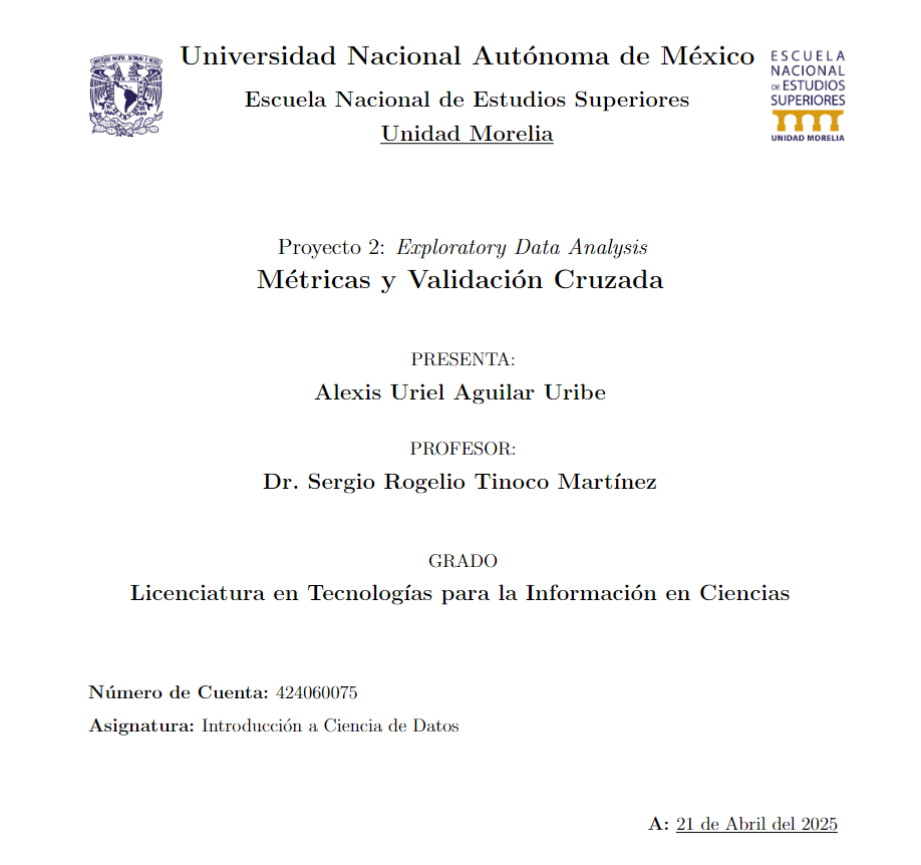
</div>

# Introduction

The following notebook contains the procedure and reasoning carried out for Data Wrangling and Cleaning. Where first the Data Wrangling was performed to homogenize the values of the attributes (to cast them into integers or float values), this process is broken down in [Data Wrangling](#2-data-wrangling). The missing values in the various records and attributes were treated according to the rules set out in [Data Cleaning: Missing Values](#3-data-cleaning-missing-values). As part of the requirements in [[1]](#references), a transformation of the target ``GDP`` was applied to convert it into a categorical attribute based on the rule stated in [Data Cleaning: Target Transformation](#4-data-cleaning-target-transformation).

In [Plot of Numerical Feature Distribution by Type of Income](#5-plot-of-numerical-feature-distribution-by-type-of-income) and [Statistical Measurement Analysis](#6-statistical-measurement-analysis), different visualizations and presentations of the data were made in order to obtain insights and additional information that can be used to define or create the model for income type classification. Where the most relevant becomes that, under the applied transformations, the income type classes can be linearly separated and that the averages can be used to represent, under certain limits, what is expected to be observed in a country belonging to a certain income type.

Finally, a hypothesis test is presented to answer the question on the dependence between ``Continent`` and ``Type of Income``, the procedure is broken down in [Does the Type of Income of a Country Depend on Which Continent it Belongs to?](#7-does-the-type-of-income-of-a-country-depend-on-which-continent-it-belongs-to), where the reasons why the Fisher's Exact Test was used together with the set of null and alternative hypotheses are also mentioned.

# 0. Import Libraries and Code

In [1]:
# Import libraries and functions

import pandas as pd
import numpy as np

from scipy.stats import fisher_exact

In [2]:
# Import functions for Data Wrangling and Cleaning

from Functions_DataWranglingCleaning import MissingValuesByFeatures , FiltersValuesBasedOnDataType , SplittingFeaturesBasedDataType , ImputationMissingValuesUsingMedian , TargetTransformation

# Import function for Plotting Data and Features

from Functions_Plot import PlotsDistributionFeatureByTarget

# 1. Dataset Loading and First Exploration

In [3]:
# Dataset loading from a xlsx file

PATH_DATASET = "../Datasets/"
CountriesInfo_Dataset = pd.read_excel(PATH_DATASET+'cia_paises.xlsx')

# Dataset dimension
CountriesInfo_Dataset.shape

(254, 14)

In [4]:
# Example of records

CountriesInfo_Dataset.head(5)

,Name,Continent,Area (km²),Population,GDP (USD),Unemployment Rate,Taxes (% of GDP),External Debt (USD),Exchange Rate (USD),Internet Users,Internet Users Percentage of Population,Airports,Roadways (km),Militar Expenditures (% of GDP)
0,Afghanistan,Asia,652230,37466414,2065,23.90,23.90,7.0,7.870,4717013.0,13.50,46.0,34903.0,1.2
1,Akrotiri,Middle East,123,18195,0,NaN,NaN,NaN,0.885,NaN,NaN,1.0,NaN,NaN
2,Albania,Europe,28748,3088385,13965,5.83,5.83,71.8,102.430,2196613.0,71.85,3.0,3945.0,1.3
3,Algeria,Africa,2381740,43576691,11511,11.70,11.70,27.5,131.085,24819531.0,59.58,149.0,104000.0,6.0
4,American Samoa,Oceania,224,46366,11200,29.80,29.80,12.2,1.000,17000.0,31.30,3.0,241.0,NaN


## 1.1 Reviewing Attributes

For each of the variables, the pertinent observations on the expected data types, data formatting and missing values are generated. This information will be used for the Data Wrangling and Preprocessing processes (Data Wrangling).

In [5]:
# Datatype by variable

CountriesInfo_Dataset.dtypes

Name                                        object
Continent                                   object
Area (km²)                                  object
Population                                  object
GDP (USD)                                    int64
Unemployment Rate                          float64
Taxes (% of GDP)                           float64
External Debt (USD)                        float64
Exchange Rate (USD)                        float64
Internet Users                             float64
Internet Users Percentage of Population    float64
Airports                                   float64
Roadways (km)                              float64
Militar Expenditures (% of GDP)            float64
dtype: object

In [6]:
# Splitting attribute into features and target

attribute_labels = CountriesInfo_Dataset.columns
Features = attribute_labels[:4].append(attribute_labels[5:])
Target = attribute_labels[4]

In [7]:
# Missing values by feature

MissingValuesByFeatures(CountriesInfo_Dataset)

Name                                        0
Continent                                   0
Area (km²)                                  0
Population                                  0
GDP (USD)                                   0
Unemployment Rate                          34
Taxes (% of GDP)                           34
External Debt (USD)                        42
Exchange Rate (USD)                        15
Internet Users                             24
Internet Users Percentage of Population    24
Airports                                   16
Roadways (km)                              23
Militar Expenditures (% of GDP)            86
dtype: int64

In [8]:
# Name 

CountriesInfo_Dataset['Name'].describe()

count             254
unique            254
top       Afghanistan
freq                1
Name: Name, dtype: object

In [9]:
# Continent

CountriesInfo_Dataset[['Continent']].value_counts(dropna=False)

Continent                        
Africa                               55
Europe                               47
Central America and the Caribbean    33
Oceania                              28
Asia                                 22
Southeast Asia                       19
Middle East                          18
South America                        13
North America                         5
Antarctic Region                      4
Arctic Region                         4
Political Map of the World            2
AsiaEurope                            1
Antarctic RegionAfrica                1
European Union                        1
World                                 1
Name: count, dtype: int64

In [10]:
# Area
## Values without numerical or ambiguous formatting 
## A value has no numeric content ['total']

CountriesInfo_Dataset[['Area (km²)']][~FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Area (km²)',int)]

,Area (km²)
8,14.2
45,1.284
77,"4,236,351 sq km"
84,total
164,1.267
240,6959.41
250,510.072 million sq km


In [11]:
# Population
## Values without numerical or ambiguous formatting 

CountriesInfo_Dataset[['Population']][~FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Population',int)]

,Population
8,no
13,no
30,uninhabited
32,no
49,uninhabited
56,no
84,no
101,uninhabited
116,no
158,uninhabited


In [12]:
# Other numerical features

CountriesInfo_Dataset[Features[4:]].describe().T

,count,mean,std,min,25%,50%,75%,max
Unemployment Rate,220.0,1.022623e+01,1.036248e+01,0.1000,3.7525,6.900000e+00,1.190750e+01,7.700000e+01
Taxes (% of GDP),220.0,1.043386e+01,1.076974e+01,0.1000,3.7525,6.900000e+00,1.194750e+01,7.700000e+01
External Debt (USD),212.0,5.385755e+01,3.321727e+01,0.0000,33.2750,4.895000e+01,6.955000e+01,2.376000e+02
Exchange Rate (USD),239.0,8.810021e+01,2.173405e+02,0.3049,1.0000,3.668400e+00,4.503250e+01,2.013000e+03
Internet Users,230.0,3.550997e+07,2.685948e+08,54.0000,233831.2500,2.313282e+06,9.221140e+06,3.960000e+09
Internet Users Percentage of Population,230.0,5.670304e+01,2.863281e+01,1.3100,31.4000,6.011500e+01,8.082250e+01,1.000000e+02
Airports,238.0,3.488109e+02,2.855758e+03,1.0000,6.0000,2.900000e+01,9.600000e+01,4.182000e+04
Roadways (km),231.0,4.756744e+05,4.319549e+06,0.0000,2020.0000,1.990100e+04,8.534050e+04,6.428501e+07
Militar Expenditures (% of GDP),168.0,2.051667e+00,2.167059e+00,0.2000,1.0925,1.600000e+00,2.305000e+00,2.400000e+01


In [13]:
# Target 

CountriesInfo_Dataset[[Target]].describe()

,GDP (USD)
count,254.000000
mean,21355.062992
std,24244.833958
min,0.000000
25%,3490.750000
50%,12747.500000
75%,32891.250000
max,139100.000000


# 2. Data Wrangling

From the review of the attributes, the ``Area`` and ``Population`` attributes must first be formatted to be numeric values.

## 2.1 Area

``Area`` values that are non-integers, verify that: they are either floats (by performing a search based on the country name, they represent millions of kilometers) or they are strings, which contain the area.

And the value with ``'total'`` is dropped.

In [14]:
# Obtaining countries' name where area is no integer

CountriesInfo_Dataset[['Name','Area (km²)']][~FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Area (km²)',int)]

,Name,Area (km²)
8,Antarctica,14.2
45,Chad,1.284
77,European Union,"4,236,351 sq km"
84,French Southern and Antarctic Lands,total
164,Niger,1.267
240,United States Pacific Island Wildlife Refuges,6959.41
250,World,510.072 million sq km


In [15]:
# Treating float values

values_float_area = FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Area (km²)',float)

CountriesInfo_Dataset.loc[values_float_area,'Area (km²)'] = (CountriesInfo_Dataset['Area (km²)'][values_float_area]*1_000_000).astype(int)

In [16]:
# Treating string values (manual)

values_string_area = FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Area (km²)',str)

CountriesInfo_Dataset.drop(index=[84],inplace=True)
CountriesInfo_Dataset.loc[values_string_area,'Area (km²)'] = [4236351 , 510072000]

In [17]:
# Recast feature as int

CountriesInfo_Dataset['Area (km²)'] = CountriesInfo_Dataset['Area (km²)'].astype(int)

## 2.2 Population

``Population`` values that are non-integers are string with the same meaning, countries without population. The latter is reinforced by the fact that they are islands.

In [18]:
# Obtaining countries' name where population is no integer

CountriesInfo_Dataset[['Name','Population']][~FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Population',int)]

,Name,Population
8,Antarctica,no
13,Ashmore and Cartier Islands,no
30,Bouvet Island,uninhabited
32,British Indian Ocean Territory,no
49,Clipperton Island,uninhabited
56,Coral Sea Islands,no
101,Heard Island and McDonald Islands,uninhabited
116,Jan Mayen,no
158,Navassa Island,uninhabited
210,South Georgia and South Sandwich Islands,no


In [19]:
# Treating string values

values_string_population = FiltersValuesBasedOnDataType(CountriesInfo_Dataset,'Population',str)

CountriesInfo_Dataset.loc[values_string_population,'Population'] = 0

In [20]:
# Recast feature as int

CountriesInfo_Dataset['Population'] = CountriesInfo_Dataset['Population'].astype(int)

# 3. Data Cleaning: Missing Values

Of the attributes with missing values, all of them are continuous numerical values, assuming that in geographic regions follow similar behaviors, the missing values are imputed using the medians (being a more robust statistic against outliers).

Using the percentage of missing values and the number of records, it is not possible to choose to eliminate records with missing values because it would greatly reduce the instances available for the training stage.

Due to the imputation rule that was defined, some geographic regions have missing values in the features of interest. From the above, it was determined to impute these values with the global median associated with these features. In addition, a record referring to the global state was detected, but for the purposes of this work it is eliminated.

In [21]:
# Percent of Missing values by feature before imputation

MissingValuesByFeatures(CountriesInfo_Dataset,True)

Name                                        0.000000
Continent                                   0.000000
Area (km²)                                  0.000000
Population                                  0.000000
GDP (USD)                                   0.000000
Unemployment Rate                          13.043478
Taxes (% of GDP)                           13.043478
External Debt (USD)                        16.205534
Exchange Rate (USD)                         5.533597
Internet Users                              9.090909
Internet Users Percentage of Population     9.090909
Airports                                    6.324111
Roadways (km)                               8.695652
Militar Expenditures (% of GDP)            33.596838
dtype: float64

In [22]:
# Splitting features based on data types

CategoricalFeatures , DiscreteFeatures , ContinuousFeatures = SplittingFeaturesBasedDataType(CountriesInfo_Dataset,Features)
NumericalFeatures = DiscreteFeatures + ContinuousFeatures

In [23]:
# Imputation of missing values using stratified median

grouping_features = 'Continent'
imputation_feature_values = ImputationMissingValuesUsingMedian(CountriesInfo_Dataset,grouping_features,ContinuousFeatures)

for feature in ContinuousFeatures:
    index_missing_values = CountriesInfo_Dataset.query(f"`{feature}` != `{feature}`").index 
    CountriesInfo_Dataset.loc[index_missing_values,feature] = CountriesInfo_Dataset.loc[index_missing_values,grouping_features].apply(imputation_feature_values(feature))

In [24]:
# Imputation of residual missing values using median

grouping_features = []
imputation_feature_values = ImputationMissingValuesUsingMedian(CountriesInfo_Dataset,grouping_features,ContinuousFeatures)

for feature in ContinuousFeatures:
    index_missing_values = CountriesInfo_Dataset.query(f"`{feature}` != `{feature}`").index 
    CountriesInfo_Dataset.loc[index_missing_values,feature] = imputation_feature_values(feature)(None)

In [25]:
# Dropping record for global status (world)

index_world = 250
CountriesInfo_Dataset.drop(index=index_world,inplace=True)

# 4. Data Cleaning: Target Transformation

In the requirements document [[1]](#references), the transformation of the attribute ``GDP (USD)`` to categorical is requested based on the following rules:

1. ``low-income`` $\implies 50 \le$ ``GDP (USD)`` $\le 5,000$

2. ``average-income`` $\implies 5,000 <$ ``GDP (USD)`` $\le 25,000$

3. ``high-income`` $\implies 25,000 <$ ``GDP (USD)``

4. Outliers are considered those whose ``GDP (USD)`` is less than $50$, and will be eliminated.

In [26]:
# Dropping outliers based on GDP values

CountriesInfo_Dataset.query("50 <= `GDP (USD)`",inplace=True)

In [27]:
# Applying target transformation

EncodedTarget = 'Type of Income'
CountriesInfo_Dataset[EncodedTarget] = TargetTransformation(CountriesInfo_Dataset,Target)

In [28]:
# Verifying transformation

rules_transformation = [
    f"50 <= `{Target}` <= 5000",
    f"5000 < `{Target}` <= 25000",
    f"25000 < `{Target}`",
]

expected_incomes = [border_name+'-income' for border_name in ['lower','average','high']]

for rule_transformation , expect_income in zip(rules_transformation,expected_incomes):
    print(f'{rule_transformation=} for {expect_income}\nIt is obtained: {CountriesInfo_Dataset.query(rule_transformation)[EncodedTarget].unique()}\n')

rule_transformation='50 <= `GDP (USD)` <= 5000' for lower-income
It is obtained: ['lower-income']

rule_transformation='5000 < `GDP (USD)` <= 25000' for average-income
It is obtained: ['average-income']

rule_transformation='25000 < `GDP (USD)`' for high-income
It is obtained: ['high-income']



# 5. Plot of Numerical Feature Distribution by Type of Income

Since the values of the attributes and target have different scales, it is necessary to apply a non-linear function (such as ``log`` or ``sqrt``) to re-scale and change the distribution of the attributes in order to make a better comparison between values. Before presenting the final plots, the functions were tested to know which one generates a better plot; from which it was determined that ``log`` is always applied to the target values.

Another criterion used to determine which function generates a better plot was to observe that the different income categories can be separated by means of a straight line. The latter is seen in all the scatter plots, making it possible for the classes (categories) to be linearly separable; the latter will allow the models to learn to classify in a simpler way and without having to use heavier or more complex elements for the model (such as creating polynomial attributes or generating new attributes by means of PCA or K-Means).

Another relevant detail is that the distribution of the values for each type of income, in most of the features, follow different distributions, this could indicate that there is a pattern that the attributes take on different types of income. And if the scatter plots are considered, it can be observed how in each type of income they follow different trends, this from the regression line, appreciating in turn how they condition, in a certain way, the values that an attribute can take.

In [29]:
# Comparison of values scale

CountriesInfo_Dataset[NumericalFeatures+[Target]].quantile([0.0,0.5,1.0])

,Area (km²),Population,Unemployment Rate,Taxes (% of GDP),External Debt (USD),Exchange Rate (USD),Internet Users,Internet Users Percentage of Population,Airports,Roadways (km),Militar Expenditures (% of GDP),GDP (USD)
0.0,2.0,6.700000e+01,0.300,0.300,0.0,0.3049,805.0,1.31,1.0,0.0,0.20,752.0
0.5,81233.5,5.583666e+06,7.145,7.145,50.4,3.8757,2353471.5,61.10,32.5,20147.5,1.55,14783.5
1.0,17098242.0,1.397898e+09,77.000,77.000,237.6,839.1000,751886119.0,99.65,13513.0,10582653.0,24.00,139100.0


In [30]:
# Transforming features and target

features_with_log_transformation = [
    'Area (km²)','Population','Internet Users',
    'Airports','Militar Expenditures (% of GDP)',
    Target
]

feature_with_sqrt_transformation = [
    'Unemployment Rate','Taxes (% of GDP)',
    'External Debt (USD)','Exchange Rate (USD)',
    'Internet Users Percentage of Population',
    'Roadways (km)',
]

CountriesInfo_Dataset_Transformed = CountriesInfo_Dataset.copy()

CountriesInfo_Dataset_Transformed[features_with_log_transformation] = np.log10(CountriesInfo_Dataset_Transformed[features_with_log_transformation])
CountriesInfo_Dataset_Transformed[feature_with_sqrt_transformation] = np.sqrt(CountriesInfo_Dataset_Transformed[feature_with_sqrt_transformation])

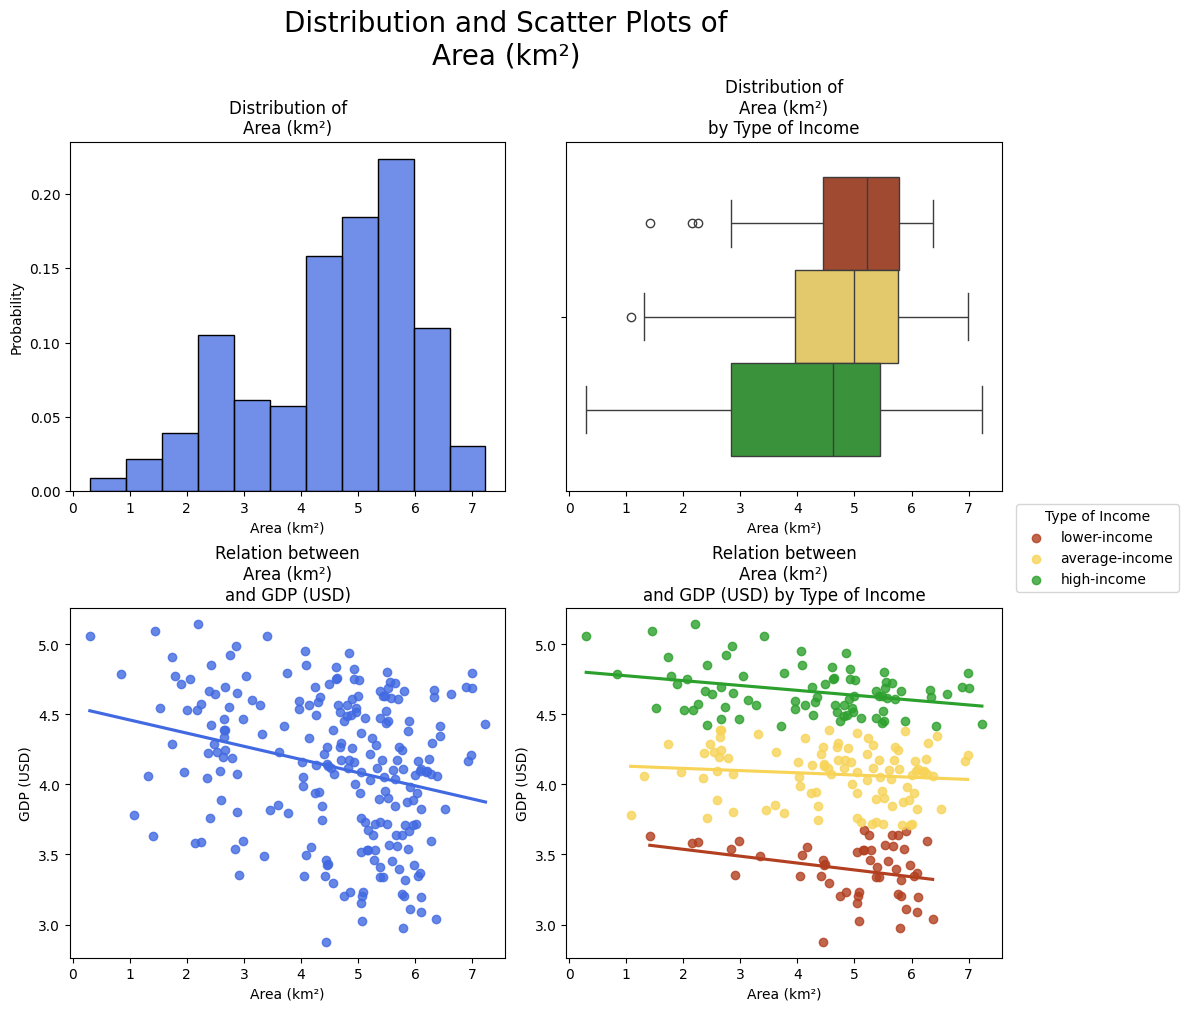

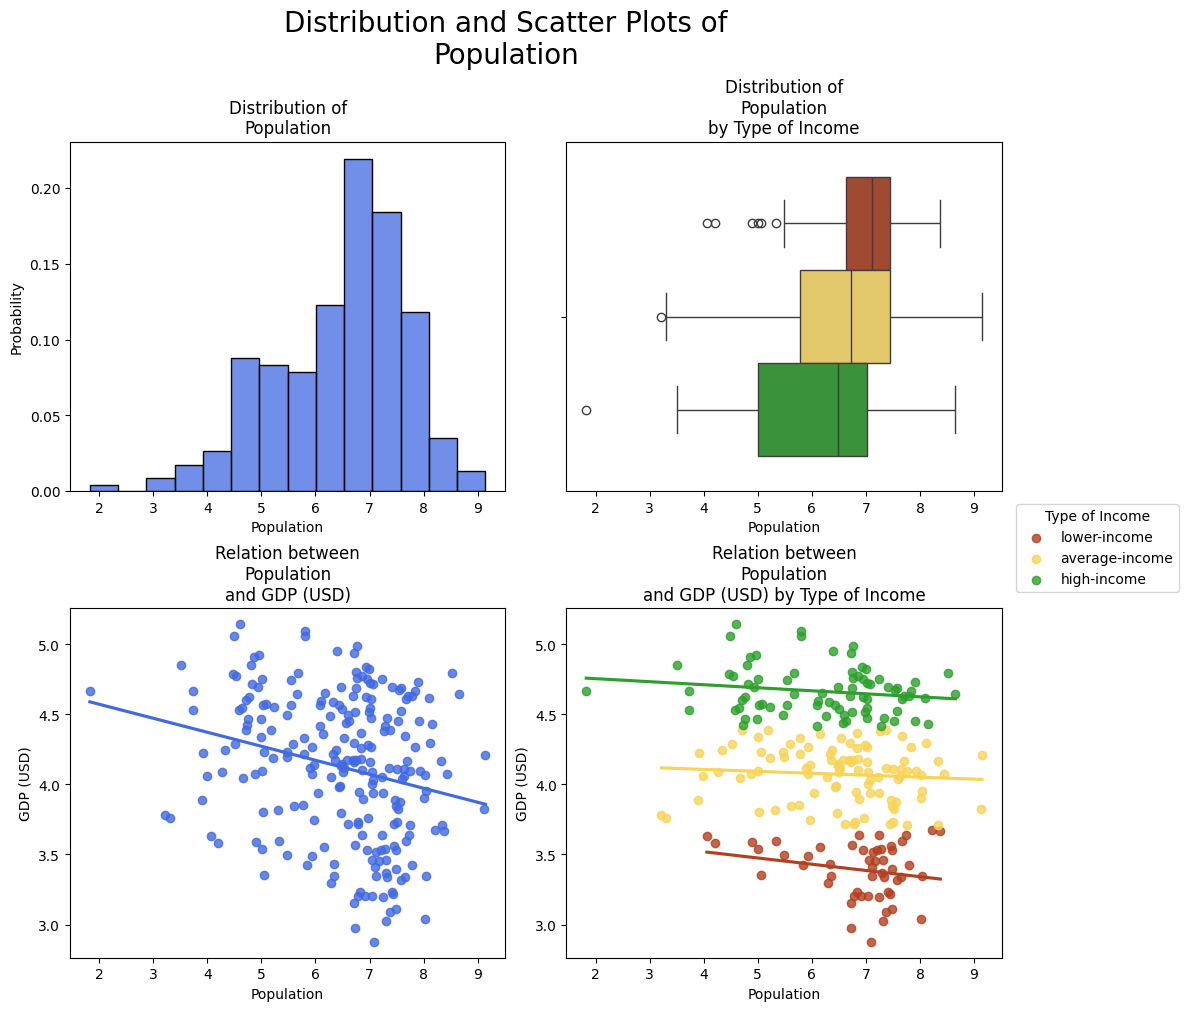

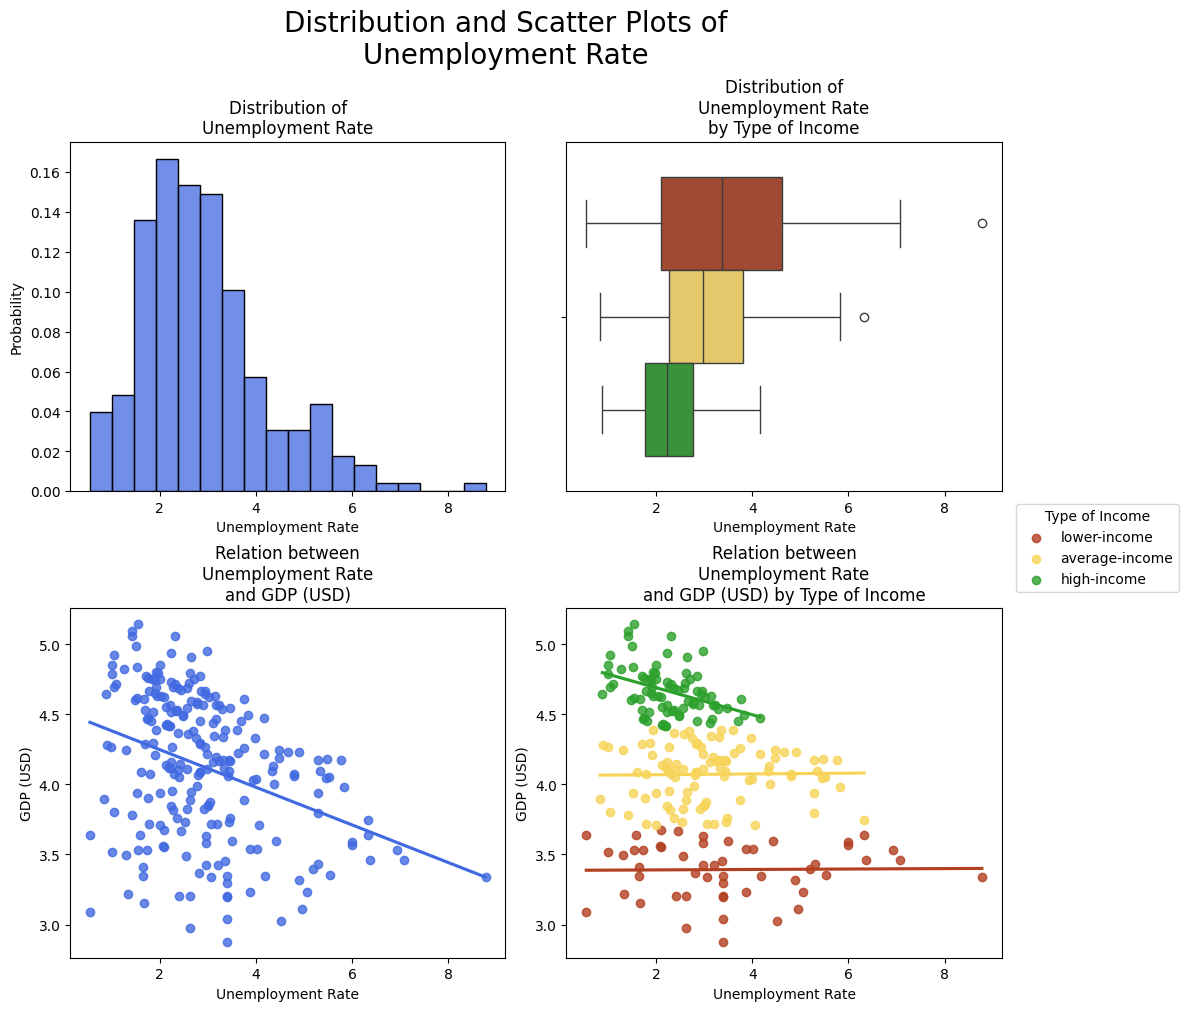

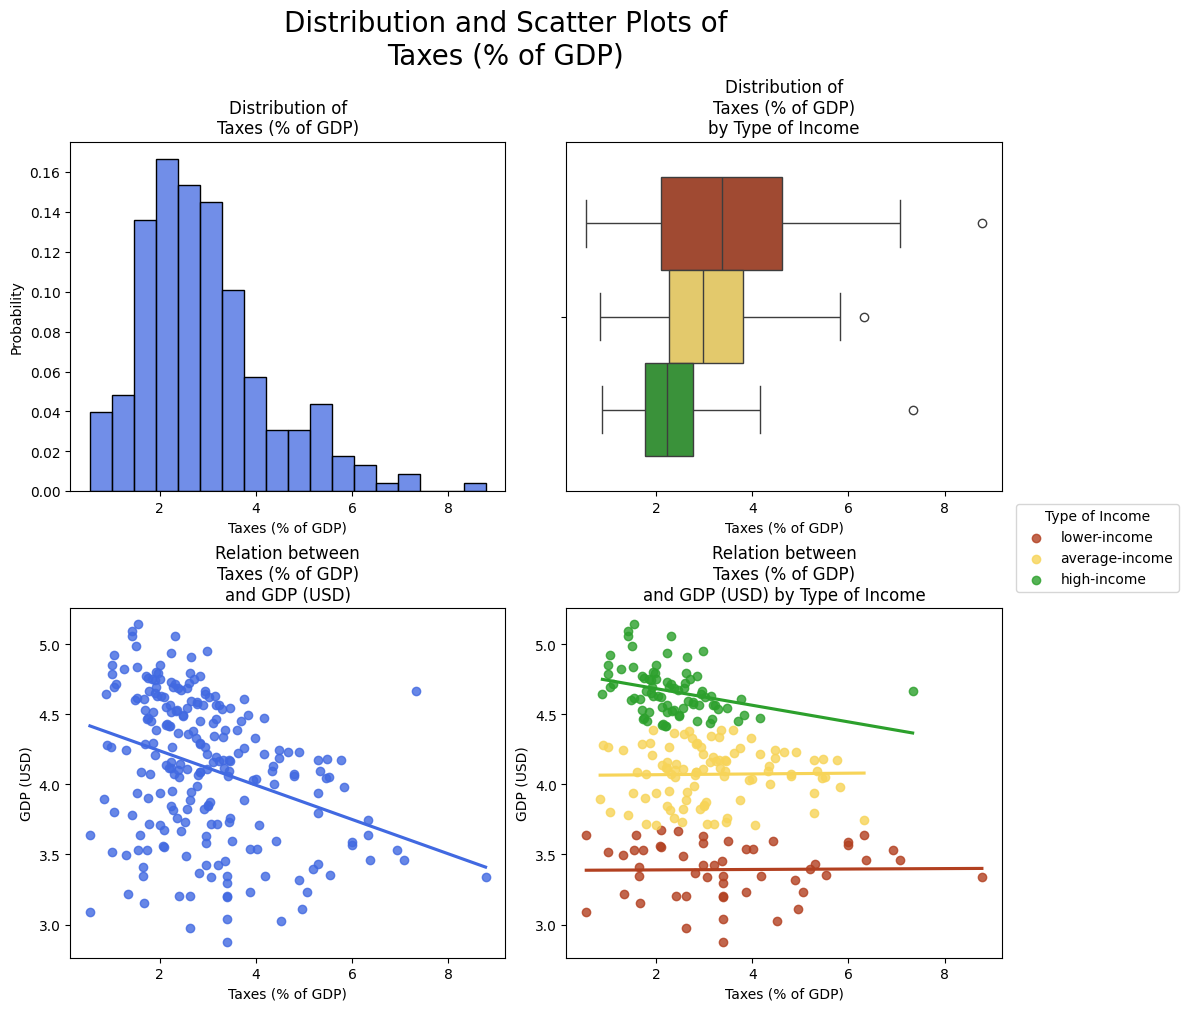

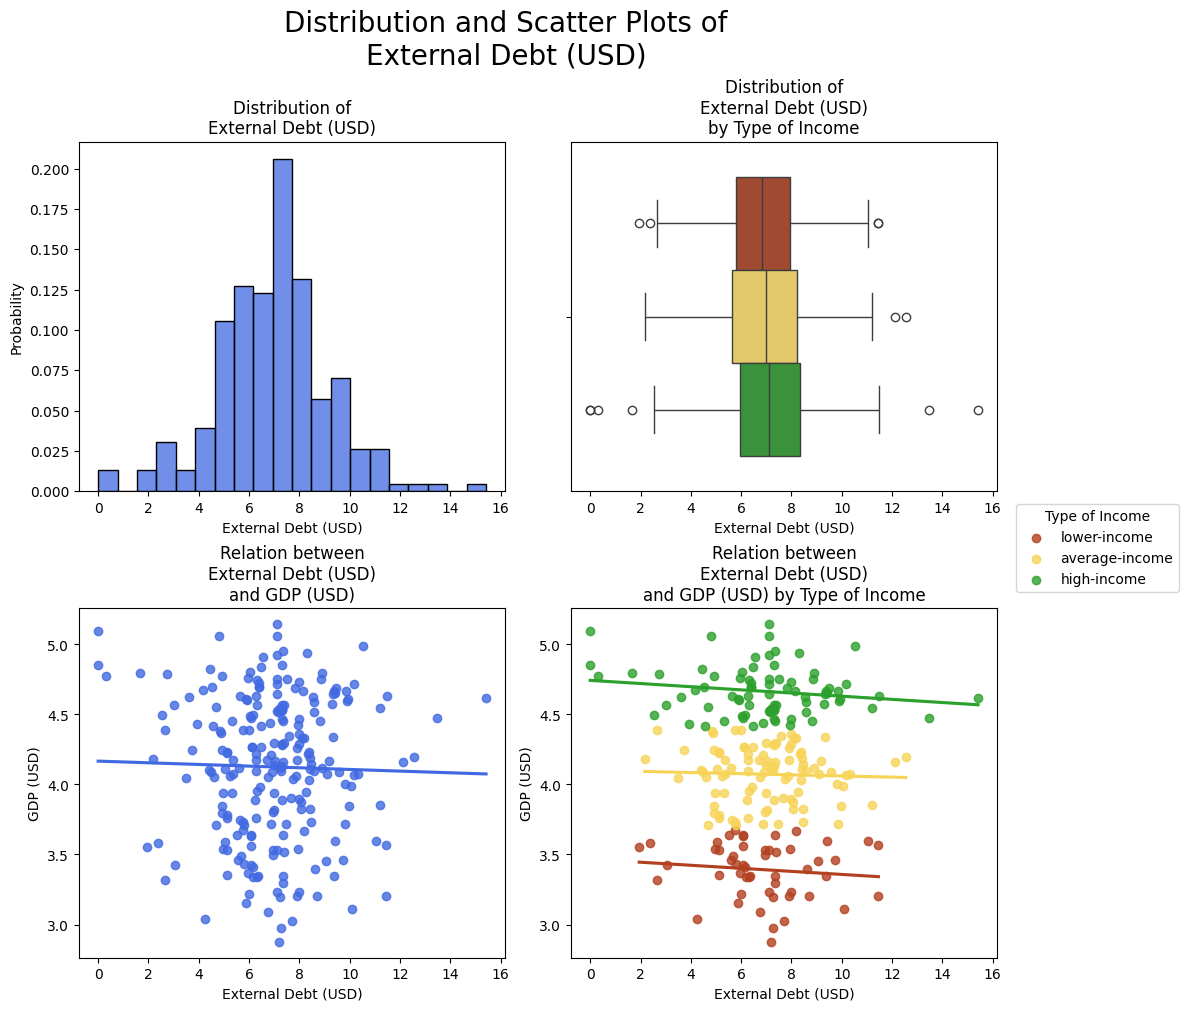

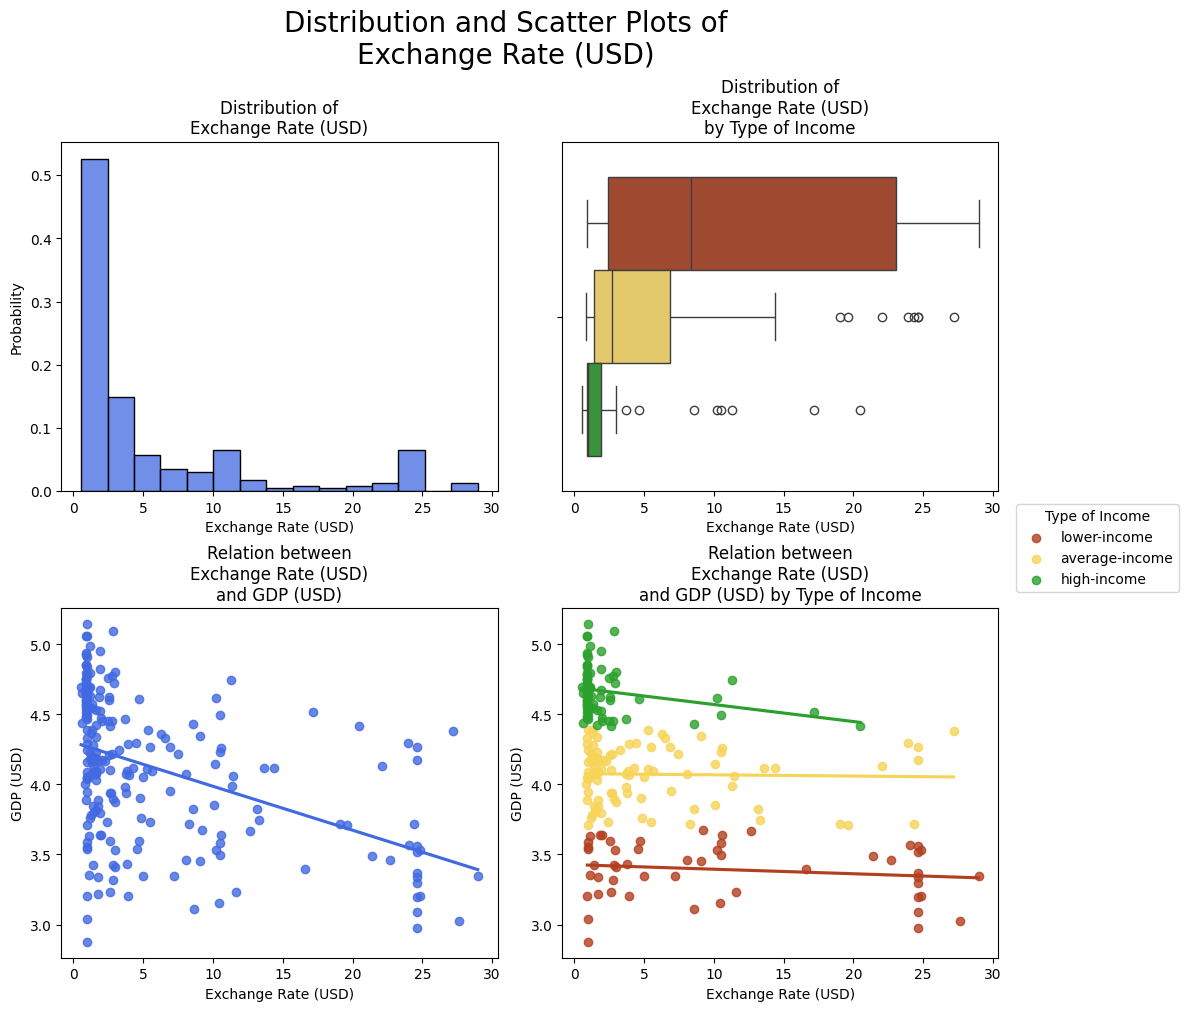

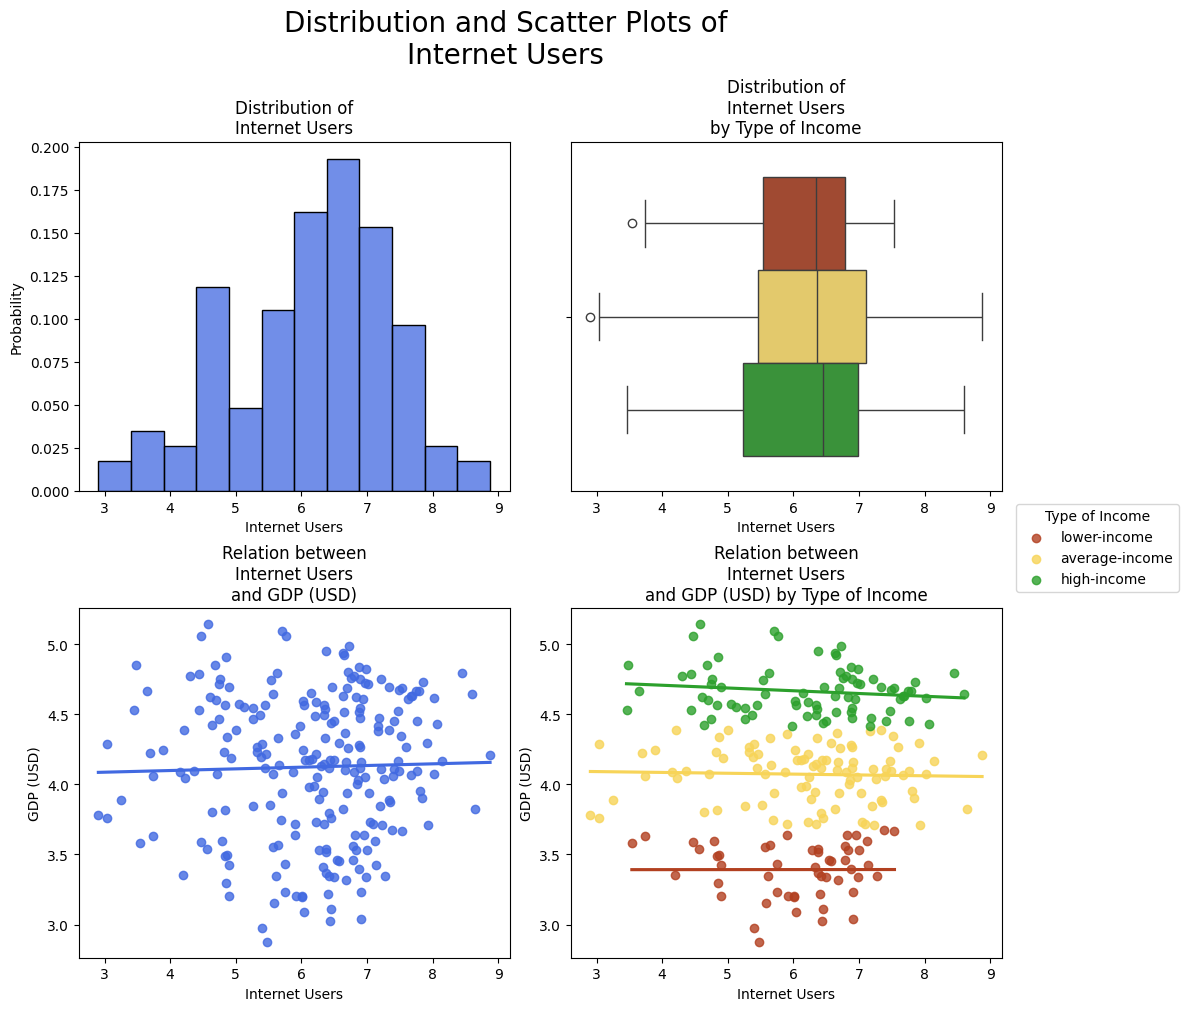

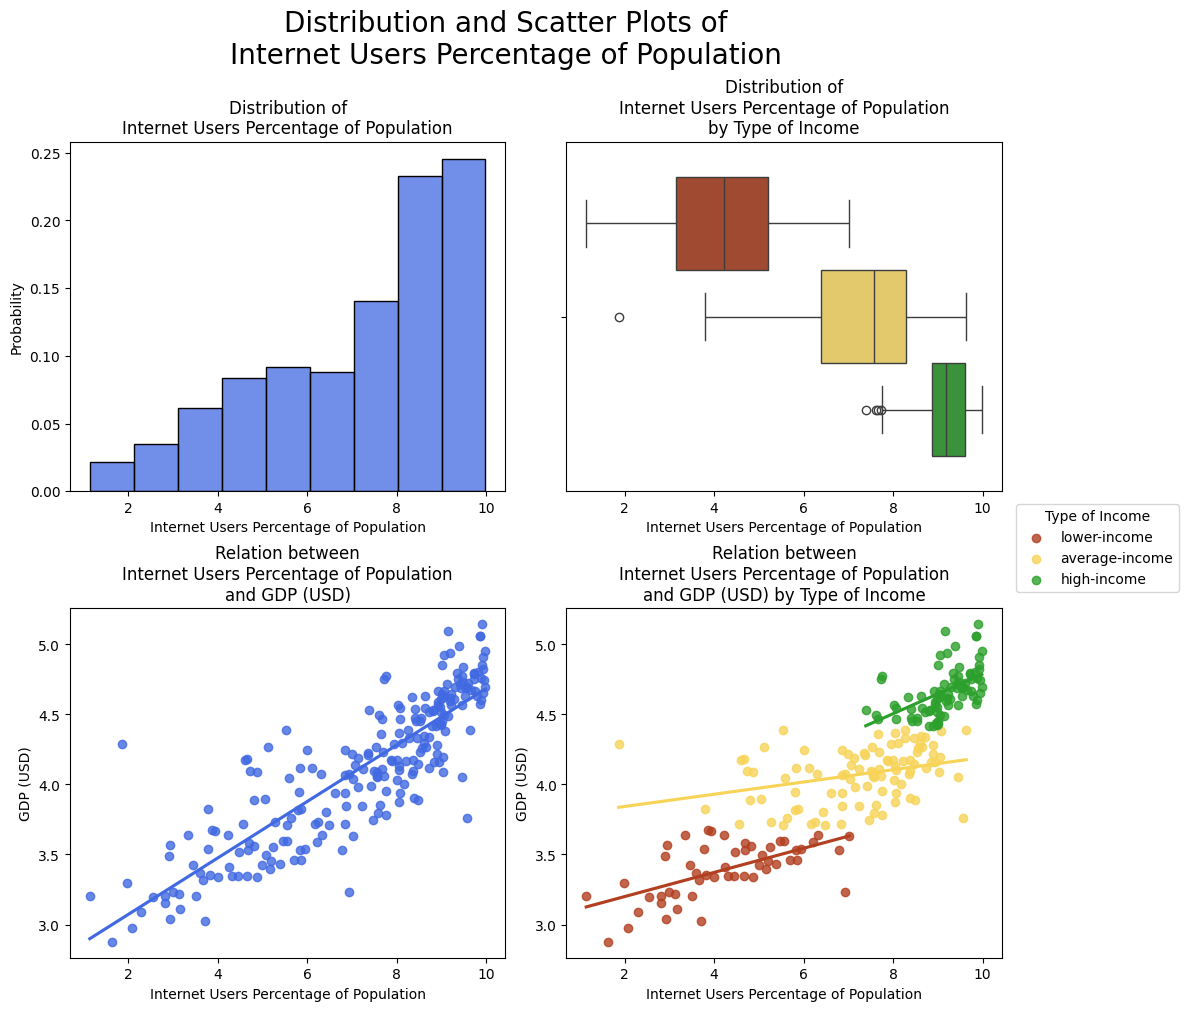

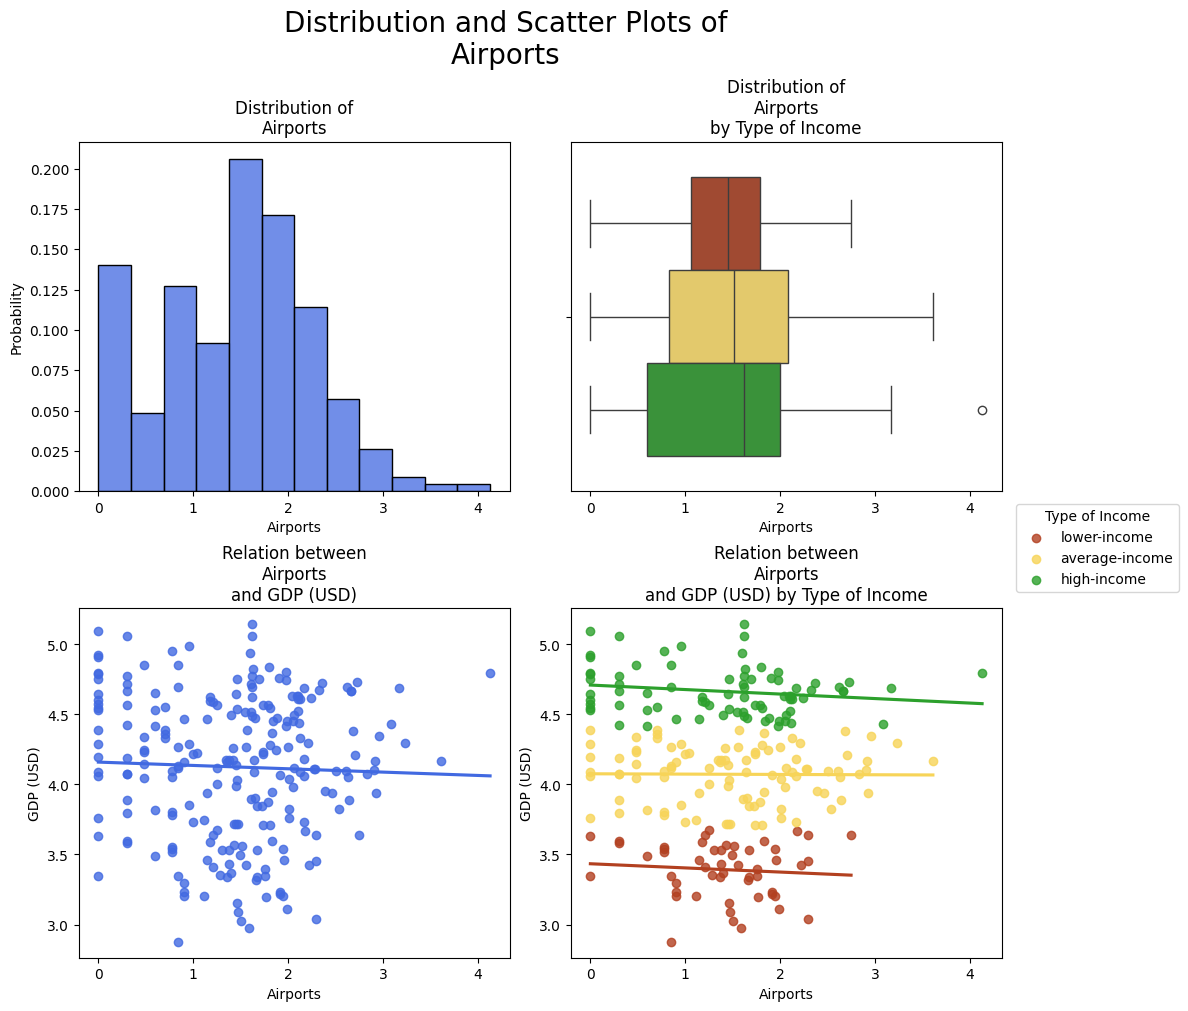

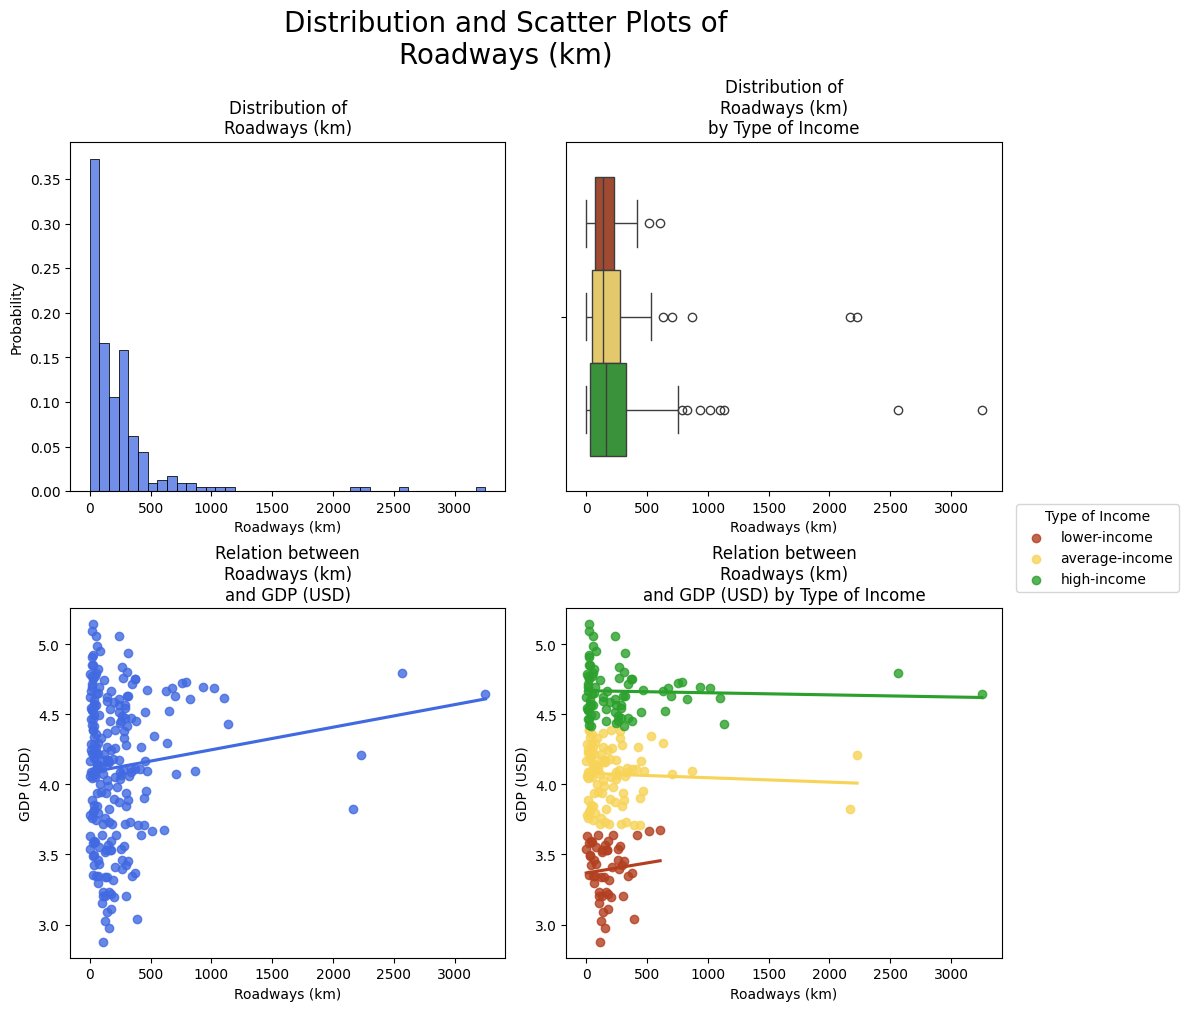

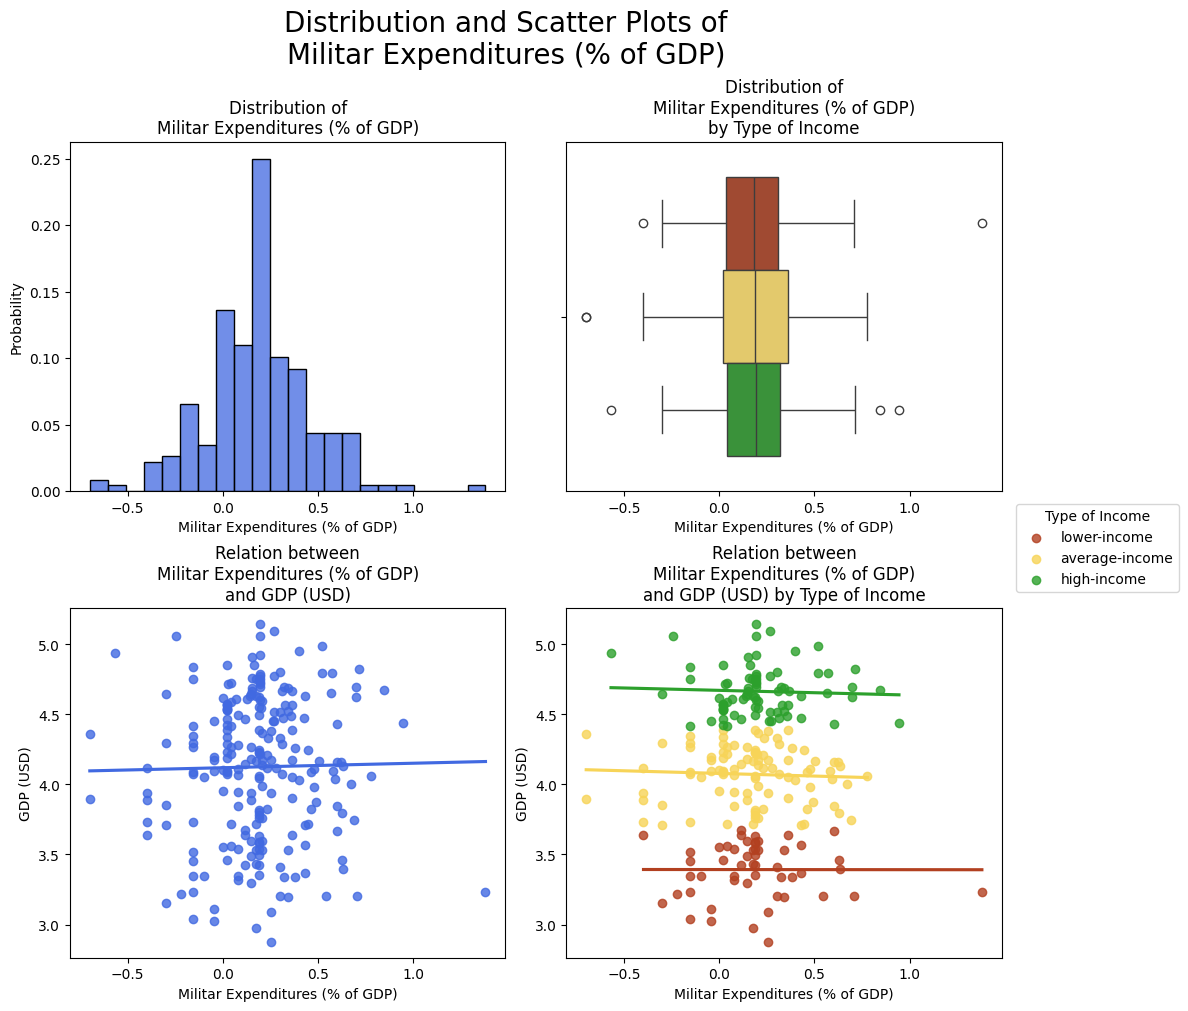

In [31]:
# Defining colors and palette

color = '#4169e1' 
palette = ['#B24020','#F7D458','#2CA02C']
palette_colors = dict(zip(expected_incomes,palette))

# Plotting distribution and scatter plots by feature

for feature in NumericalFeatures:
    PlotsDistributionFeatureByTarget(CountriesInfo_Dataset_Transformed,feature,Target,EncodedTarget,color,palette_colors)

# 6. Statistical Measurement Analysis

Using the mean of the attributes to obtain extra insights from the dataset, it can be seen how in each type of income there are different means per attribute (it is possible that there are no significant differences), making it possible to characterize each type of income in the sense that from the mean we can determine what we expect to observe in the countries that have a certain type of income and even if it is more similar to certain means we can determine, with some certainty, to which type of income it belongs.

In [32]:
# Mean of numerical attributes

CountriesInfo_Dataset_Transformed[NumericalFeatures+[Target,EncodedTarget]].groupby(EncodedTarget).mean()

,Area (km²),Population,Unemployment Rate,Taxes (% of GDP),External Debt (USD),Exchange Rate (USD),Internet Users,Internet Users Percentage of Population,Airports,Roadways (km),Militar Expenditures (% of GDP),GDP (USD)
Type of Income,,,,,,,,,,,,
average-income,4.666177,6.511693,3.142384,3.142384,7.032217,5.529974,6.201122,7.258354,1.498619,222.926300,0.161734,4.072756
high-income,4.201256,6.183526,2.267849,2.323915,6.925425,2.259920,6.211527,9.127114,1.395153,309.345199,0.206994,4.665010
lower-income,4.947836,6.857845,3.499522,3.499522,6.821479,10.814890,6.026922,4.236272,1.403657,170.521746,0.186260,3.392256


# 7. Does the Type of Income of a Country Depend on Which Continent it Belongs to?

One of the questions of interest for the project relates to whether belonging to a certain continent favors having a higher type of income. Therefore, the following hypothesis is posed:

$$H_0 : \text{Continent and Type of Income are Independents}$$
$$H_1 : \text{Continent and Type of Income are not Independents}$$

For testing the hypotheses, the Fisher's Exact Test is used, because it is not suggested to use the $\chi^2$ test when there is a very large table or when many of the entries in the table have less than $5$ observations; as can be seen from the contingency table generated, both conditions for not using the $\chi^2$ test are verified.

Performing the Fisher's Exact Test with a significance $\alpha$ of $5\%$, the null hypothesis is rejected, since its p-value is $0.0001$. The above implies that the variables ``Continent`` and ``Type of Income`` are dependent, so that in certain continents countries with more favorable or better types of income can be observed.

In [33]:
# Calculating type of income by continent

Observations_ContinentIncome = CountriesInfo_Dataset_Transformed.pivot_table(values='Name',index=EncodedTarget,columns='Continent',aggfunc='count',fill_value=0)

Observations_ContinentIncome

Continent,Africa,Arctic Region,Asia,AsiaEurope,Central America and the Caribbean,Europe,European Union,Middle East,North America,Oceania,South America,Southeast Asia
Type of Income,,,,,,,,,,,,
average-income,20,0,12,1,18,9,0,5,1,11,12,7
high-income,1,2,4,0,12,37,1,9,4,4,1,5
lower-income,33,0,6,0,1,0,0,2,0,8,0,2


In [34]:
# Applying Fisher test for dependence of variables

statistics , p_value = fisher_exact(Observations_ContinentIncome)
print(f'The P-Value of the test is {p_value}\nIts statistics is: {statistics}')

The P-Value of the test is 0.0001
Its statistics is: 1.283118615954396e-40


# 8. Save Preprocessed and Cleaned Dataset

From the different plots generated, it is possible to appreciate the outliers that are found but that will have to be assumed at the time of training the model, since there is not enough data to choose to eliminate the few that are marked as outliers. But from the observations and insights generated, it can be concluded that the impact (bias) related to the outliers will not be noticeable, especially if they follow the trends of the other elements belonging to the same type of income.

The dataset that is saved is the one that has neither the attributes nor the target transformed under the ``log`` or ``sqrt`` functions. These transformations will be applied in the preprocessing stage of the model pipeline. The ``Name`` attribute is removed because it does not represent a significant attribute for predicting the GDP of a country.

In [35]:
# Saving cleaned dataset (without transformed features nor target)

CountriesInfo_Dataset[Features.to_list()+[Target,EncodedTarget]].drop(columns=['Name']).to_csv(PATH_DATASET+'cia_paises_cleaned.csv',index=False)

# Conclusions

Throughout this notebook was presented all the necessary procedure to perform the Data Wrangling of the provided data set, where I took advantage of some techniques to carry it out. In the section [Data Wrangling](#2-data-wrangling) I recovered the ``~`` trick to apply the logical operator NOT, in this case, on a NumPy array. Following with the [Data Cleaning: Missing Values](#3-data-cleaning-missing-values) section I found a way to impute several values in a stratified manner at the same time taking advantage of how NumPy array indices work; and this same trick I used but in [Data Cleaning: Target Transformation](#4-data-cleaning-target-transformation) so that once knowing what type of entry a country belongs to, returning that numeric value to a string value (more suitable for value plots).

In the section [Plot of Numerical Feature Distribution by Type of Income](#5-plot-of-numerical-feature-distribution-by-type-of-income) was where I learned the most, because presenting the same data but in two different ways allowed me to understand how applying an appropriate function to transform numerical values into categorical values allows me to generate a data visualization that better clarifies certain ideas or generates new questions. And this technique is a very interesting trick but at the same time very complex, how to create a decision edge or even how to divide an attribute in a way that generates the classes or categories desired; but when everything is done in a proper way you can get more meaningful insights and knowledge for the project or work.

And in the section [Does the Type of Income of a Country Depend on Which Continent it Belongs to?](#7-does-the-type-of-income-of-a-country-depend-on-which-continent-it-belongs-to) I recovered what I learned in the “Descriptive Statistics and Inference” classes for hypothesis testing: from proposing the set of hypotheses, choosing the test and interpreting the results. The above, was what I did to reach the exposed conclusion.

# References

* [1] [Proyecto 2: *Métricas y Validación Cruzada*](../RequirementsDocument.pdf). Tinoco Martinez Sergio Rogelio
* [2] DataFrame. Pandas. https://pandas.pydata.org/docs/reference/frame.html
* [3] API Reference. Seaborn. https://seaborn.pydata.org/api.html
* [4] API Reference. Matplotlib development team. https://matplotlib.org/stable/api/index.html
* [5] SciPy API. The SciPy community. https://docs.scipy.org/doc/scipy/reference/index.html#scipy-api